# Support Vector Machine

Entrena un `SVC` con kernel RBF para predecir `is_hit` (exito comercial).
Incluye busqueda de hiperparametros con submuestra, permutation importance y proyeccion PCA-2D.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

from src.evaluacion import mostrar_metricas, graficar_confusion


## 1. Cargar datos

In [2]:
X_train = pd.read_csv('../data/processed/X_train_clf.csv')
X_test  = pd.read_csv('../data/processed/X_test_clf.csv')
y_train = pd.read_csv('../data/processed/y_train_clf.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test_clf.csv').squeeze()
nombres_features = X_train.columns.tolist()

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')


Train: (12000, 17)  |  Test: (3000, 17)


## 2. Submuestra para GridSearch

SVM con kernel RBF tiene complejidad O(n^2) en entrenamiento. Con 12,000 filas el GridSearch seria muy lento.
Se usan 5,000 filas aleatorias para la busqueda y se refit en el conjunto completo.

In [3]:
X_sample = X_train.sample(5000, random_state=42)
y_sample = y_train[X_sample.index]
print(f'Submuestra para GridSearch: {X_sample.shape}')


Submuestra para GridSearch: (5000, 17)


## 3. Busqueda de hiperparametros (GridSearchCV)

In [4]:
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1],
}

svm = SVC(probability=True, random_state=42)
grid = GridSearchCV(svm, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid.fit(X_sample, y_sample)

print('Mejores parametros:', grid.best_params_)
print(f'Mejor F1 en CV: {grid.best_score_:.4f}')


Mejores parametros: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Mejor F1 en CV: 0.9108


## 4. Reentrenar con mejores parametros en datos completos

In [5]:
mejor_svm = SVC(**grid.best_params_, probability=True, random_state=42)
mejor_svm.fit(X_train, y_train)
print(f'Modelo reentrenado: kernel={mejor_svm.kernel}, C={mejor_svm.C}, gamma={mejor_svm.gamma}')


Modelo reentrenado: kernel=rbf, C=1, gamma=0.01


## 5. Importancia de features (Permutation Importance)

SVM no tiene importancias directas como el arbol. Se usa permutation importance:
medir cuanto cae el F1 al aleatorizar cada feature en el conjunto de test.

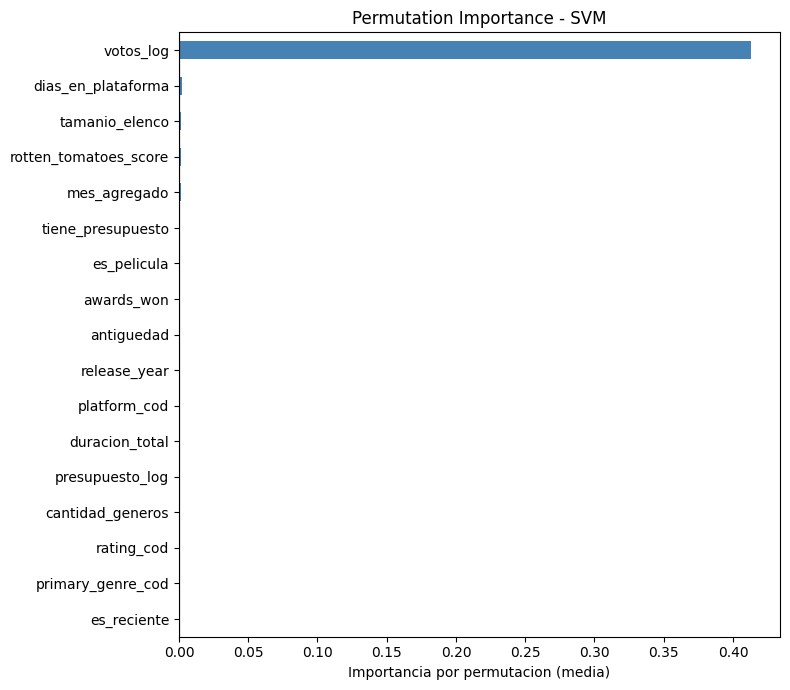

In [6]:
y_pred = mejor_svm.predict(X_test)

perm = permutation_importance(
    mejor_svm, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
importancias = pd.Series(perm.importances_mean, index=nombres_features).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colores = ['steelblue' if v > 0 else 'lightgray' for v in importancias]
importancias.plot(kind='barh', ax=ax, color=colores)
ax.set_xlabel('Importancia por permutacion (media)')
ax.set_title('Permutation Importance - SVM')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/figures/13_permutation_svm.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Proyeccion PCA-2D

Visualiza la separabilidad de las clases en el espacio de 2 componentes principales,
coloreando cada punto segun la prediccion del SVM.

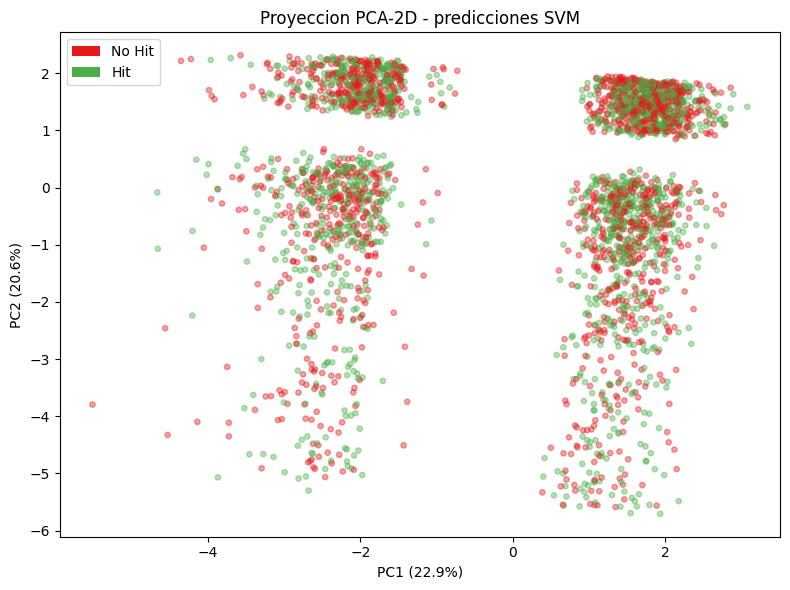

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test)

from matplotlib.patches import Patch
colores_pred = ['#e41a1c' if p == 0 else '#4daf4a' for p in y_pred]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colores_pred, alpha=0.4, s=15)
leyenda = [Patch(facecolor='#e41a1c', label='No Hit'), Patch(facecolor='#4daf4a', label='Hit')]
ax.legend(handles=leyenda)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Proyeccion PCA-2D - predicciones SVM')
plt.tight_layout()
plt.savefig('../reports/figures/14_pca_svm.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Metricas en test

In [8]:
metricas_svm = mostrar_metricas(y_test, y_pred, 'SVM')


--- SVM ---
  Accuracy  : 0.9120
  Precision : 0.9121
  Recall    : 0.9120
  F1-Score  : 0.9120


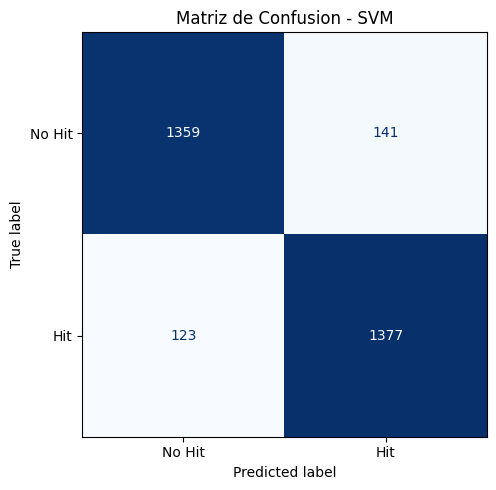

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Hit', 'Hit']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusion - SVM')
plt.tight_layout()
plt.savefig('../reports/figures/conf_matrix_svm.png', dpi=150, bbox_inches='tight')
plt.show()


ROC-AUC: 0.9752


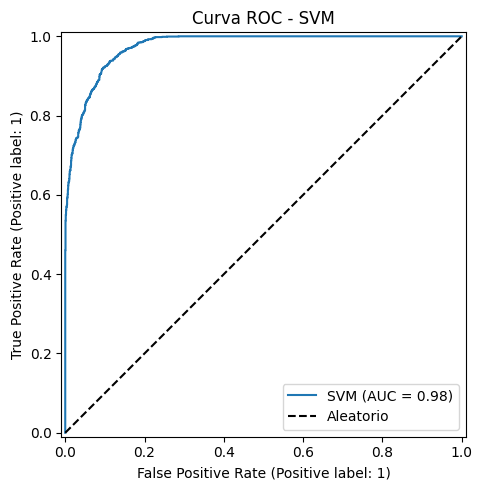

In [10]:
y_proba = mejor_svm.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC: {auc:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, name='SVM', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title('Curva ROC - SVM')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/15_roc_svm.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Guardar modelo

In [11]:
joblib.dump(mejor_svm, '../models/svm.joblib')
print('Modelo guardado: models/svm.joblib')
metricas_svm['roc_auc'] = round(auc, 4)
print(metricas_svm)


Modelo guardado: models/svm.joblib
{'modelo': 'SVM', 'accuracy': 0.912, 'precision': 0.9120593365444625, 'recall': 0.912, 'f1': 0.9119968318859478, 'roc_auc': np.float64(0.9752)}
